## Imports

In [1]:
from utils.SpokenDigitDataset import SpokenDigitDataset
from utils.DatasetSplitter import DatasetSplitter
from models.ResNet import ResNet18
import torch.nn as nn
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Dataset, random_split
import matplotlib.pyplot as plt
import librosa.display
import wandb
from torch.optim.lr_scheduler import ReduceLROnPlateau
from utils.Metrics import multiclass_f1_score, multiclass_confusion_matrix
import time


## Dataset

Etiqueta: tensor(1)


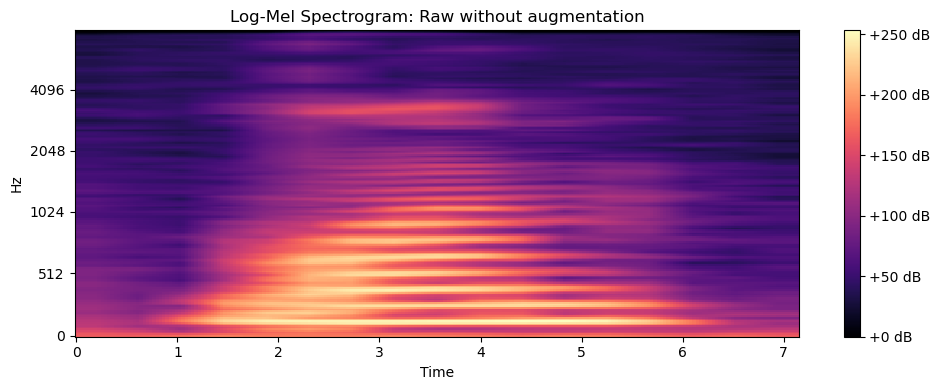

Etiqueta: tensor(1)


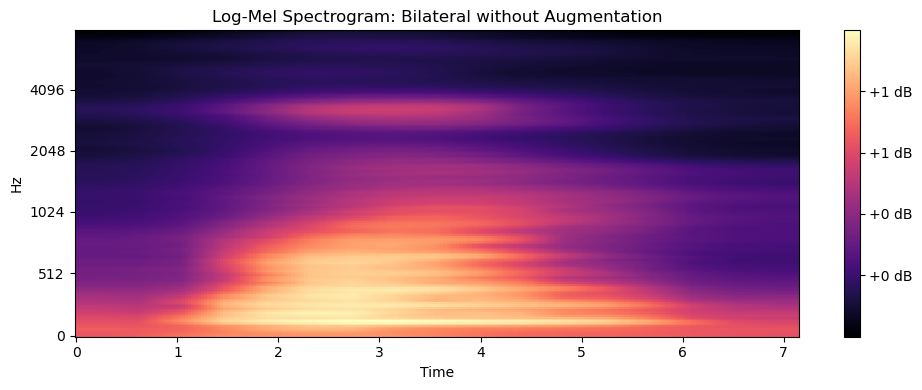

Etiqueta: tensor(1)


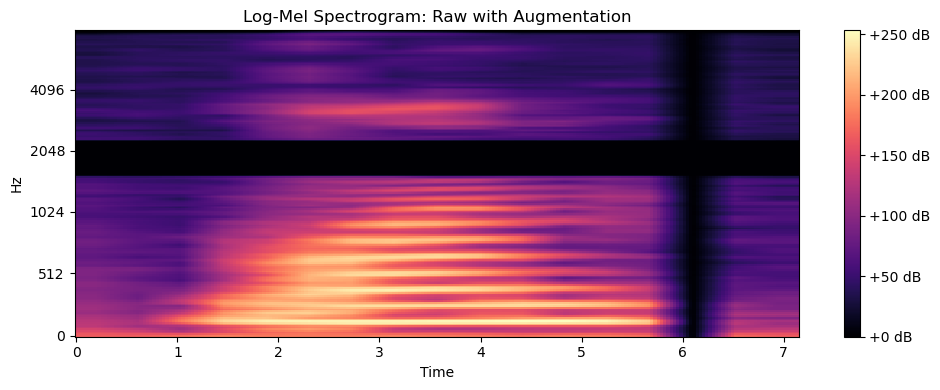

Etiqueta: tensor(1)


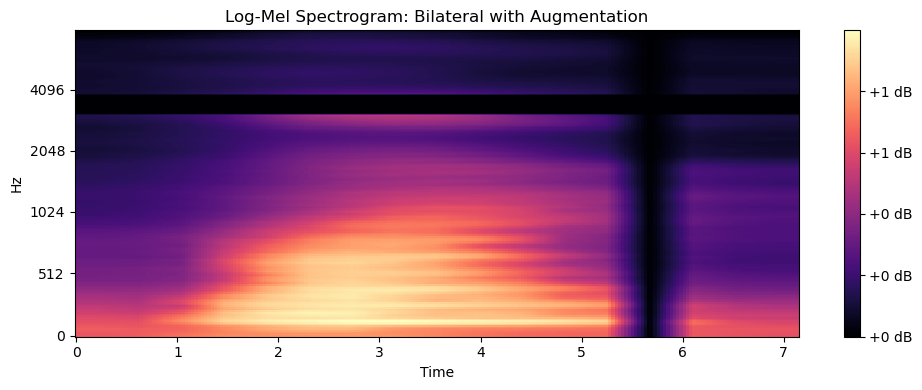

In [2]:
dataset = SpokenDigitDataset("/data/lnavarro/tec/proyecto-2/data/audio")

# This will automatically perform the split upon creation
splitter = DatasetSplitter(
        dataset=dataset,
        split_ratios=(0.7, 0.15, 0.15) # Example: 70% train, 15% val, 15% test
)

# You can access the split datasets:
train_set = splitter.train_dataset
val_set = splitter.val_dataset
test_set = splitter.test_dataset

# print(f"\nAccessed train_set (Subset): Size {len(train_set)}")
# print(f"Accessed val_set (Subset): Size {len(val_set)}")
# print(f"Accessed test_set (Subset): Size {len(test_set)}")

# You can configure the underlying dataset for each split
# For example, enable augmentation only for the training set


# Check the configuration of the underlying dataset for a split
# print(f"\nTrain dataset underlying config after configure_splits: Bilateral={train_set.dataset.bilateral}, Augment={train_set.dataset.augment}")
# print(f"Validation dataset underlying config after configure_splits: Bilateral={val_set.dataset.bilateral}, Augment={val_set.dataset.augment}")
# print(f"Test dataset underlying config after configure_splits: Bilateral={test_set.dataset.bilateral}, Augment={test_set.dataset.augment}")


# You can access the DataLoaders:
train_loader = splitter.train_dataloader
val_loader = splitter.val_dataloader
test_loader = splitter.test_dataloader


splitter.configure_splits(bilateral=False, augment=False)
x, y = train_set[0]
print("Etiqueta:", y)
plt.figure(figsize=(10, 4))
librosa.display.specshow(x.squeeze().numpy(), sr=16000, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram: Raw without augmentation')
plt.tight_layout()
plt.show()

splitter.configure_splits(bilateral=True, augment=False)
x, y = train_set[0]
print("Etiqueta:", y)
plt.figure(figsize=(10, 4))
librosa.display.specshow(x.squeeze().numpy(), sr=16000, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram: Bilateral without Augmentation')
plt.tight_layout()
plt.show()

splitter.configure_splits(bilateral=False, augment=True)

x, y = train_set[0]
print("Etiqueta:", y)
plt.figure(figsize=(10, 4))
librosa.display.specshow(x.squeeze().numpy(), sr=16000, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram: Raw with Augmentation')
plt.tight_layout()
plt.show()

splitter.configure_splits(bilateral=True, augment=True)

x, y = train_set[0]
print("Etiqueta:", y)
plt.figure(figsize=(10, 4))
librosa.display.specshow(x.squeeze().numpy(), sr=16000, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram: Bilateral with Augmentation')
plt.tight_layout()
plt.show()



## Modelo B: ResNet18

#### Set Device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Training

In [4]:
def train(training_data_loader, model, loss_function, optimizer, scheduler, num_classes=10):
    model.train()
    correct = 0
    losses = []
    f1_scores = []
    
    for inputs, labels in training_data_loader:
        inputs, labels = inputs.cuda(), labels.cuda()
        optimizer.zero_grad()
        out = model(inputs)
        loss = loss_function(out, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss)
        # print(loss)
        f1_score = multiclass_f1_score(out.argmax(1), labels, num_classes=num_classes)
        f1_scores.append(f1_score)
        correct += (out.argmax(1) == labels).sum().item()
        
        

    mean_loss = sum(losses)/len(losses)
    mean_acc = correct/len(training_data_loader.dataset) * 100.
    mean_f1 = sum(f1_scores)/len(f1_scores)

    scheduler.step(mean_loss)

    return mean_loss, mean_acc, mean_f1


#### Validation

In [5]:
def validate(validation_data_loader, model, loss_function, num_classes=10):
    model.eval()
    with torch.no_grad():
        correct = 0
        f1_scores = []
        losses = []
        for inputs, labels in validation_data_loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            out = model(inputs)
            loss = loss_function(out, labels)
            losses.append(loss)
            f1_score = multiclass_f1_score(out.argmax(1), labels, num_classes=num_classes)
            f1_scores.append(f1_score)
            correct += (out.argmax(1) == labels).sum().item()
        
        mean_loss = sum(losses)/len(losses)
        mean_acc = correct/len(validation_data_loader.dataset) * 100.
        mean_f1 = sum(f1_scores)/len(f1_scores)

        return mean_loss, mean_acc, mean_f1

#### Test

In [6]:
def test(test_data_loader, model, num_classes=10):
    model.eval()
    correct = 0
    with torch.no_grad():
        all_preds = []
        all_labels = []
        for inputs, labels in test_data_loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            out = model(inputs)
            correct += (out.argmax(1) == labels).sum().item()
            all_preds.extend(out.argmax(1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

        class_names = [str(i) for i in range(num_classes)]

        wandb.log({
            "conf_matrix": wandb.plot.confusion_matrix(y_true=all_labels, preds=all_preds, class_names=class_names)
        })
        
        mean_acc = correct/len(test_data_loader.dataset) * 100.
        mean_f1 = multiclass_f1_score(all_preds, all_labels, num_classes=num_classes)
        return mean_acc, mean_f1
        


#### Try Model Hyperparams

In [7]:
def try_resnet_model(epochs, lr, splitter, val_loader, test_loader, bilateral=False, augmentation=False):
    wandb.init(
        project="Audio-mnist",
        name=f"resnet-audio-{'No' if not bilateral else ''}Bi-{'No' if not augmentation else ''}Aug-try",
        tags=["not-final", "resnet"],
        config={
            "epochs": epochs,
            "batch_size": 32,
            "learning_rate": lr,
            "architecture": "ResNet18Audio",
            "input_size": "1x224x224",
            "num_classes": 10,
            "bilateral_filter": bilateral,
            "augmentation": augmentation
        }
    )
    splitter.configure_splits(wandb.config.bilateral_filter, wandb.config.augmentation)

    model = ResNet18(wandb.config.num_classes).to(device)
    loss_function = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=wandb.config.learning_rate)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    for epoch in range(wandb.config.epochs):
        start_time = time.time()
        mean_loss, mean_acc, mean_f1 = train(val_loader, model, loss_function, optimizer, scheduler)

        wandb.log({
            "epoch": epoch + 1,
            "train/loss": mean_loss,
            "train/accuracy": mean_acc,
            "train/f1": mean_f1,
        })


        print(f"Epoch #{epoch+1} ({(time.time()-start_time):.1f}s):\n\tLoss={mean_loss:.4f} Acc={mean_acc:.2f}%")


    test_acc, test_f1 = test(test_data_loader=test_loader, model=model)

    wandb.log({
        "test/accuracy": test_acc,
        "test/f1_score": test_f1
    })


#### Run Model

In [9]:
def run_resnet_model(epochs, lr, splitter, train_loader, val_loader, test_loader, bilateral=False, augmentation=False):
    wandb.init(
        project="Audio-mnist",
        name=f"resnet-audio-{'No' if not bilateral else ''}Bi-{'No' if not augmentation else ''}Aug-run",
        tags=["resnet"],
        config={
            "epochs": epochs,
            "batch_size": 32,
            "learning_rate": lr,
            "architecture": "ResNet18Audio",
            "input_size": "1x224x224",
            "num_classes": 10,
            "bilateral_filter": bilateral,
            "augmentation": augmentation
        }
    )
    splitter.configure_splits(wandb.config.bilateral_filter, wandb.config.augmentation)

    model = ResNet18(wandb.config.num_classes).to(device)
    loss_function = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=wandb.config.learning_rate)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    for epoch in range(wandb.config.epochs):
        start_time = time.time()
        val_loss, val_acc, val_f1 = validate(val_loader, model, loss_function)
        # val_loss, val_acc, val_f1 = 0, 0, 0
        mean_loss, mean_acc, mean_f1 = train(train_loader, model, loss_function, optimizer, scheduler)

        wandb.log({
            "epoch": epoch + 1,
            "train/loss": mean_loss,
            "train/accuracy": mean_acc,
            "train/f1": mean_f1,
            "validation/loss": val_loss,
            "validation/accuracy": val_acc,
            "validation/f1": val_f1
        })


        print(f"Epoch #{epoch+1} ({(time.time()-start_time):.1f}s):\n\tLoss={mean_loss:.4f}, Val_Loss={val_loss:.4f}, Acc={mean_acc:.2f}%, Val_Acc={val_acc:.2f}%")


    test_acc, test_f1 = test(test_data_loader=test_loader, model=model)

    wandb.log({
        "test/accuracy": test_acc,
        "test/f1_score": test_f1
    })



## Grid Search for HyperParams: LR and Epochs

#### No Augmentation and No Filter

In [9]:
try_resnet_model(4, 0.0001, splitter, val_loader, test_loader, bilateral=False, augmentation=False)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: luiscantodd (luiscantodd-tec-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch #1 (110.3s):
	Loss=2.0204 Acc=37.60%
Epoch #2 (109.9s):
	Loss=1.6929 Acc=61.49%
Epoch #3 (109.5s):
	Loss=1.4790 Acc=70.40%
Epoch #4 (109.8s):
	Loss=1.3095 Acc=75.40%


In [10]:
try_resnet_model(4, 0.00005, splitter, val_loader, test_loader, bilateral=False, augmentation=False)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▃▁
epoch,4
test/accuracy,71.24444
test/f1_score,0.0203
train/accuracy,75.4
train/f1,0.02189


Epoch #1 (83.6s):
	Loss=2.1292 Acc=26.98%
Epoch #2 (85.0s):
	Loss=1.8985 Acc=48.56%
Epoch #3 (88.9s):
	Loss=1.7373 Acc=59.31%
Epoch #4 (87.3s):
	Loss=1.6049 Acc=66.82%


In [11]:
try_resnet_model(4, 0.0004, splitter, val_loader, test_loader, bilateral=False, augmentation=False)

epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▃▁
epoch,4
test/accuracy,69.11111
test/f1_score,0.01952
train/accuracy,66.82222
train/f1,0.01893


Epoch #1 (78.3s):
	Loss=1.8084 Acc=46.00%
Epoch #2 (76.9s):
	Loss=1.2889 Acc=71.00%
Epoch #3 (78.4s):
	Loss=0.9520 Acc=82.18%
Epoch #4 (77.7s):
	Loss=0.7185 Acc=87.42%


In [12]:
try_resnet_model(4, 0.0002, splitter, val_loader, test_loader, bilateral=False, augmentation=False)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▂▁
epoch,4
test/accuracy,72.02222
test/f1_score,0.02081
train/accuracy,87.42222
train/f1,0.0258


Epoch #1 (78.5s):
	Loss=1.9227 Acc=38.27%
Epoch #2 (77.3s):
	Loss=1.5431 Acc=63.62%
Epoch #3 (78.1s):
	Loss=1.2713 Acc=75.13%
Epoch #4 (77.8s):
	Loss=1.0592 Acc=81.73%


In [9]:
try_resnet_model(4, 0.0003, splitter, val_loader, test_loader, bilateral=False, augmentation=False)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: luiscantodd (luiscantodd-tec-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch #1 (122.5s):
	Loss=1.7742 Acc=48.93%
Epoch #2 (109.8s):
	Loss=1.3268 Acc=71.56%
Epoch #3 (109.9s):
	Loss=1.0248 Acc=80.96%
Epoch #4 (109.8s):
	Loss=0.8121 Acc=85.82%


### Augmentation and No Bilateral Filter

In [13]:
try_resnet_model(4, 0.0001, splitter, val_loader, test_loader, bilateral=False, augmentation=True)

epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▃▁
epoch,4
test/accuracy,83.77778
test/f1_score,0.02456
train/accuracy,81.73333
train/f1,0.02402


Epoch #1 (78.9s):
	Loss=2.0891 Acc=29.29%
Epoch #2 (78.5s):
	Loss=1.8796 Acc=43.67%
Epoch #3 (78.3s):
	Loss=1.7165 Acc=52.91%
Epoch #4 (78.8s):
	Loss=1.5742 Acc=60.62%


In [14]:
try_resnet_model(4, 0.00001, splitter, val_loader, test_loader, bilateral=False, augmentation=True)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▄▆█
train/f1,▁▄▆█
train/loss,█▅▃▁
epoch,4
test/accuracy,59.4
test/f1_score,0.0162
train/accuracy,60.62222
train/f1,0.01674


Epoch #1 (78.6s):
	Loss=2.3505 Acc=12.51%
Epoch #2 (77.2s):
	Loss=2.2526 Acc=14.73%
Epoch #3 (78.5s):
	Loss=2.1756 Acc=18.80%
Epoch #4 (78.7s):
	Loss=2.1209 Acc=23.76%


In [15]:
try_resnet_model(4, 0.00008, splitter, val_loader, test_loader, bilateral=False, augmentation=True)

epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▂▅█
train/f1,▁▂▅█
train/loss,█▅▃▁
epoch,4
test/accuracy,26.46667
test/f1_score,0.00584
train/accuracy,23.75556
train/f1,0.00494


Epoch #1 (78.8s):
	Loss=2.0782 Acc=29.73%
Epoch #2 (79.0s):
	Loss=1.8599 Acc=47.11%
Epoch #3 (78.4s):
	Loss=1.7201 Acc=55.13%
Epoch #4 (78.5s):
	Loss=1.5959 Acc=61.27%


In [16]:
try_resnet_model(4, 0.00025, splitter, val_loader, test_loader, bilateral=False, augmentation=True)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▃▁
epoch,4
test/accuracy,60.71111
test/f1_score,0.01661
train/accuracy,61.26667
train/f1,0.01705


Epoch #1 (78.8s):
	Loss=2.0334 Acc=31.47%
Epoch #2 (78.5s):
	Loss=1.6859 Acc=52.31%
Epoch #3 (78.7s):
	Loss=1.4129 Acc=64.96%
Epoch #4 (77.9s):
	Loss=1.2046 Acc=72.02%


### No Augmentation and Bilateral Filter

In [17]:
try_resnet_model(4, 0.0001, splitter, val_loader, test_loader, bilateral=True, augmentation=False)

epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▃▁
epoch,4
test/accuracy,69.02222
test/f1_score,0.01955
train/accuracy,72.02222
train/f1,0.02064


Epoch #1 (76.9s):
	Loss=2.0025 Acc=35.38%
Epoch #2 (76.7s):
	Loss=1.6159 Acc=66.80%
Epoch #3 (76.8s):
	Loss=1.3900 Acc=75.56%
Epoch #4 (77.0s):
	Loss=1.2194 Acc=81.36%


In [18]:
try_resnet_model(4, 0.0003, splitter, val_loader, test_loader, bilateral=True, augmentation=False)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▆▇█
train/f1,▁▆▇█
train/loss,█▅▃▁
epoch,4
test/accuracy,82.2
test/f1_score,0.0241
train/accuracy,81.35556
train/f1,0.02379


Epoch #1 (77.4s):
	Loss=1.7377 Acc=53.42%
Epoch #2 (77.5s):
	Loss=1.2291 Acc=73.89%
Epoch #3 (77.7s):
	Loss=0.9338 Acc=83.62%
Epoch #4 (77.8s):
	Loss=0.7187 Acc=89.38%


In [19]:
try_resnet_model(4, 0.0005, splitter, val_loader, test_loader, bilateral=True, augmentation=False)

epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▂▁
epoch,4
test/accuracy,83.8
test/f1_score,0.02451
train/accuracy,89.37778
train/f1,0.02651


Epoch #1 (76.5s):
	Loss=1.6419 Acc=53.80%
Epoch #2 (76.1s):
	Loss=1.0424 Acc=78.84%
Epoch #3 (76.5s):
	Loss=0.6847 Acc=88.93%
Epoch #4 (76.5s):
	Loss=0.4906 Acc=92.33%


In [20]:
try_resnet_model(4, 0.00007, splitter, val_loader, test_loader, bilateral=True, augmentation=False)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▆▇█
train/f1,▁▆▇█
train/loss,█▄▂▁
epoch,4
test/accuracy,71.71111
test/f1_score,0.02052
train/accuracy,92.33333
train/f1,0.02741


Epoch #1 (76.8s):
	Loss=2.1185 Acc=26.09%
Epoch #2 (76.4s):
	Loss=1.7658 Acc=54.73%
Epoch #3 (76.9s):
	Loss=1.5455 Acc=70.20%
Epoch #4 (77.7s):
	Loss=1.3831 Acc=76.38%


### Augmentation and Bilateral Filter

In [21]:
try_resnet_model(4, 0.0001, splitter, val_loader, test_loader, bilateral=True, augmentation=True)

epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▃▁
epoch,4
test/accuracy,81.11111
test/f1_score,0.02392
train/accuracy,76.37778
train/f1,0.02187


Epoch #1 (77.0s):
	Loss=2.0778 Acc=33.73%
Epoch #2 (76.7s):
	Loss=1.7827 Acc=56.13%
Epoch #3 (76.7s):
	Loss=1.5816 Acc=65.58%
Epoch #4 (76.9s):
	Loss=1.4338 Acc=70.31%


In [22]:
try_resnet_model(4, 0.0002, splitter, val_loader, test_loader, bilateral=True, augmentation=True)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▃▁
epoch,4
test/accuracy,69.37778
test/f1_score,0.01957
train/accuracy,70.31111
train/f1,0.02008


Epoch #1 (76.9s):
	Loss=1.9235 Acc=41.53%
Epoch #2 (76.8s):
	Loss=1.5286 Acc=64.49%
Epoch #3 (76.9s):
	Loss=1.2903 Acc=73.47%
Epoch #4 (76.0s):
	Loss=1.1075 Acc=78.71%


In [23]:
try_resnet_model(4, 0.00005, splitter, val_loader, test_loader, bilateral=True, augmentation=True)

epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▃▁
epoch,4
test/accuracy,70.11111
test/f1_score,0.01959
train/accuracy,78.71111
train/f1,0.02284


Epoch #1 (77.5s):
	Loss=2.1810 Acc=24.27%
Epoch #2 (77.3s):
	Loss=1.9592 Acc=43.42%
Epoch #3 (77.0s):
	Loss=1.8251 Acc=53.60%
Epoch #4 (76.6s):
	Loss=1.7091 Acc=61.22%


In [24]:
try_resnet_model(4, 0.000075, splitter, val_loader, test_loader, bilateral=True, augmentation=True)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▃▁
epoch,4
test/accuracy,52
test/f1_score,0.0138
train/accuracy,61.22222
train/f1,0.0169


Epoch #1 (76.9s):
	Loss=2.1536 Acc=25.89%
Epoch #2 (76.9s):
	Loss=1.8867 Acc=51.13%
Epoch #3 (76.7s):
	Loss=1.7053 Acc=60.84%
Epoch #4 (76.7s):
	Loss=1.5646 Acc=66.07%


## Model Execution

### No Augmentation and No Bilateral Filter

In [26]:
run_resnet_model(15, 0.0003, splitter, train_loader, val_loader, test_loader, bilateral=False, augmentation=False)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▃▆█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇█
train/f1,▁▅▇█
train/loss,█▅▃▁
epoch,4
test/accuracy,84.24444
test/f1_score,0.84106
train/accuracy,85.82222
train/f1,0.02532


Epoch #1 (508.9s):
	Loss=1.2226, Val_Loss=5.9115, Acc=71.52%, Val_Acc=10.89%
Epoch #2 (437.0s):
	Loss=0.4474, Val_Loss=0.7358, Acc=93.29%, Val_Acc=86.18%
Epoch #3 (435.3s):
	Loss=0.2224, Val_Loss=0.3632, Acc=96.78%, Val_Acc=93.47%
Epoch #4 (434.3s):
	Loss=0.1420, Val_Loss=0.5648, Acc=97.84%, Val_Acc=82.64%
Epoch #5 (435.1s):
	Loss=0.0980, Val_Loss=0.4138, Acc=98.63%, Val_Acc=86.29%
Epoch #6 (433.0s):
	Loss=0.0731, Val_Loss=0.2052, Acc=99.01%, Val_Acc=95.33%
Epoch #7 (434.4s):
	Loss=0.0578, Val_Loss=0.1654, Acc=99.16%, Val_Acc=94.69%
Epoch #8 (435.1s):
	Loss=0.0509, Val_Loss=0.5485, Acc=99.24%, Val_Acc=79.20%
Epoch #9 (436.6s):
	Loss=0.0394, Val_Loss=0.1005, Acc=99.40%, Val_Acc=97.82%
Epoch #10 (435.9s):
	Loss=0.0327, Val_Loss=0.0319, Acc=99.55%, Val_Acc=99.53%
Epoch #11 (436.6s):
	Loss=0.0295, Val_Loss=0.0531, Acc=99.51%, Val_Acc=98.98%
Epoch #12 (434.8s):
	Loss=0.0258, Val_Loss=0.0550, Acc=99.57%, Val_Acc=98.93%
Epoch #13 (434.3s):
	Loss=0.0256, Val_Loss=0.0473, Acc=99.58%, Val_Acc=98

### Augmentation and No Bilateral Filter

In [27]:
run_resnet_model(18, 0.00025, splitter, train_loader, val_loader, test_loader, bilateral=False, augmentation=True)

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▆▇████████████
train/f1,▁▆▇▇███████████
train/loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁
validation/accuracy,▁▇█▇▇██▆█████▇█
validation/f1,▁▇█▇▇██▆█████▇█
validation/loss,█▂▁▂▁▁▁▂▁▁▁▁▁▁▁
epoch,15
test/accuracy,99.37778


Epoch #1 (460.5s):
	Loss=1.4438, Val_Loss=8.3027, Acc=60.65%, Val_Acc=10.07%
Epoch #2 (437.4s):
	Loss=0.7505, Val_Loss=1.0426, Acc=84.84%, Val_Acc=74.13%
Epoch #3 (438.5s):
	Loss=0.4657, Val_Loss=0.7654, Acc=90.82%, Val_Acc=81.49%
Epoch #4 (436.0s):
	Loss=0.3315, Val_Loss=0.3566, Acc=93.50%, Val_Acc=92.62%
Epoch #5 (442.1s):
	Loss=0.2497, Val_Loss=0.6241, Acc=94.99%, Val_Acc=79.76%
Epoch #6 (438.1s):
	Loss=0.2068, Val_Loss=0.2755, Acc=95.60%, Val_Acc=92.60%
Epoch #7 (436.8s):
	Loss=0.1676, Val_Loss=0.2152, Acc=96.66%, Val_Acc=94.31%
Epoch #8 (438.0s):
	Loss=0.1453, Val_Loss=0.2772, Acc=96.81%, Val_Acc=91.02%
Epoch #9 (437.1s):
	Loss=0.1256, Val_Loss=0.1581, Acc=97.33%, Val_Acc=96.02%
Epoch #10 (436.6s):
	Loss=0.1142, Val_Loss=0.2489, Acc=97.58%, Val_Acc=91.24%
Epoch #11 (434.9s):
	Loss=0.1002, Val_Loss=0.3432, Acc=97.74%, Val_Acc=88.00%
Epoch #12 (435.0s):
	Loss=0.0857, Val_Loss=0.1464, Acc=98.15%, Val_Acc=96.33%
Epoch #13 (435.8s):
	Loss=0.0818, Val_Loss=0.2862, Acc=98.20%, Val_Acc=90

### No Augmentation and Bilateral Filter

In [28]:
run_resnet_model(15, 0.0003, splitter, train_loader, val_loader, test_loader, bilateral=True, augmentation=False)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▅▇▇▇▇████████████
train/f1,▁▅▇▇▇▇████████████
train/loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
validation/accuracy,▁▆▇█▇██▇█▇▇█▇█▇███
validation/f1,▁▆▇█▆██▇█▇▇█▇█▇███
validation/loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,18
test/accuracy,98.64444


Epoch #1 (556.4s):
	Loss=1.0845, Val_Loss=2.3054, Acc=78.13%, Val_Acc=9.60%
Epoch #2 (427.8s):
	Loss=0.3795, Val_Loss=0.9029, Acc=94.63%, Val_Acc=73.27%
Epoch #3 (429.4s):
	Loss=0.1990, Val_Loss=0.7370, Acc=97.22%, Val_Acc=72.44%
Epoch #4 (425.4s):
	Loss=0.1295, Val_Loss=0.2194, Acc=98.09%, Val_Acc=95.98%
Epoch #5 (418.3s):
	Loss=0.0948, Val_Loss=0.2270, Acc=98.60%, Val_Acc=95.96%
Epoch #6 (418.8s):
	Loss=0.0734, Val_Loss=0.1312, Acc=98.85%, Val_Acc=96.76%
Epoch #7 (418.9s):
	Loss=0.0586, Val_Loss=0.1606, Acc=99.07%, Val_Acc=95.44%
Epoch #8 (419.5s):
	Loss=0.0502, Val_Loss=0.4451, Acc=99.19%, Val_Acc=86.56%
Epoch #9 (428.2s):
	Loss=0.0461, Val_Loss=0.0629, Acc=99.22%, Val_Acc=98.53%
Epoch #10 (419.7s):
	Loss=0.0379, Val_Loss=0.1083, Acc=99.35%, Val_Acc=96.71%
Epoch #11 (418.7s):
	Loss=0.0355, Val_Loss=0.2839, Acc=99.33%, Val_Acc=89.76%
Epoch #12 (418.2s):
	Loss=0.0325, Val_Loss=0.2825, Acc=99.36%, Val_Acc=90.20%
Epoch #13 (419.3s):
	Loss=0.0304, Val_Loss=0.1024, Acc=99.46%, Val_Acc=96.

In [9]:
run_resnet_model(18, 0.0001, splitter, train_loader, val_loader, test_loader, bilateral=True, augmentation=False)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: luiscantodd (luiscantodd-tec-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch #1 (1288.5s):
	Loss=1.4716, Val_Loss=2.3040, Acc=68.67%, Val_Acc=10.58%
Epoch #2 (446.6s):
	Loss=0.8170, Val_Loss=1.0574, Acc=89.40%, Val_Acc=82.31%
Epoch #3 (435.5s):
	Loss=0.5256, Val_Loss=0.6384, Acc=93.55%, Val_Acc=91.47%
Epoch #4 (434.7s):
	Loss=0.3652, Val_Loss=0.4391, Acc=95.81%, Val_Acc=95.67%
Epoch #5 (436.3s):
	Loss=0.2703, Val_Loss=0.2948, Acc=96.83%, Val_Acc=97.13%
Epoch #6 (434.6s):
	Loss=0.2101, Val_Loss=0.3344, Acc=97.59%, Val_Acc=90.40%
Epoch #7 (433.6s):
	Loss=0.1656, Val_Loss=0.1758, Acc=98.06%, Val_Acc=97.20%
Epoch #8 (434.8s):
	Loss=0.1365, Val_Loss=0.2062, Acc=98.30%, Val_Acc=96.02%
Epoch #9 (434.1s):
	Loss=0.1097, Val_Loss=0.1044, Acc=98.80%, Val_Acc=98.76%
Epoch #10 (436.0s):
	Loss=0.0937, Val_Loss=0.1134, Acc=98.85%, Val_Acc=98.76%
Epoch #11 (434.3s):
	Loss=0.0799, Val_Loss=0.1797, Acc=99.05%, Val_Acc=96.64%
Epoch #12 (435.0s):
	Loss=0.0702, Val_Loss=0.0875, Acc=99.17%, Val_Acc=98.58%
Epoch #13 (432.3s):
	Loss=0.0641, Val_Loss=0.1039, Acc=99.08%, Val_Acc=9

### Augmentation and Bilateral Filter

In [10]:
run_resnet_model(18, 0.0002, splitter, train_loader, val_loader, test_loader, bilateral=True, augmentation=True)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: luiscantodd (luiscantodd-tec-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch #1 (933.4s):
	Loss=1.4413, Val_Loss=2.3081, Acc=62.80%, Val_Acc=9.93%
Epoch #2 (453.2s):
	Loss=0.7712, Val_Loss=1.2740, Acc=85.35%, Val_Acc=56.33%
Epoch #3 (432.0s):
	Loss=0.4981, Val_Loss=0.7679, Acc=91.06%, Val_Acc=78.31%
Epoch #4 (431.5s):
	Loss=0.3604, Val_Loss=0.5969, Acc=93.38%, Val_Acc=82.76%
Epoch #5 (432.5s):
	Loss=0.2733, Val_Loss=0.3052, Acc=94.91%, Val_Acc=94.00%
Epoch #6 (430.5s):
	Loss=0.2265, Val_Loss=1.0350, Acc=95.66%, Val_Acc=66.87%
Epoch #7 (431.8s):
	Loss=0.1902, Val_Loss=0.2201, Acc=96.22%, Val_Acc=95.07%
Epoch #8 (430.9s):
	Loss=0.1622, Val_Loss=0.2129, Acc=96.86%, Val_Acc=94.62%
Epoch #9 (429.3s):
	Loss=0.1434, Val_Loss=0.4552, Acc=96.99%, Val_Acc=83.36%
Epoch #10 (431.4s):
	Loss=0.1248, Val_Loss=0.1400, Acc=97.39%, Val_Acc=97.16%
Epoch #11 (431.2s):
	Loss=0.1142, Val_Loss=0.2299, Acc=97.50%, Val_Acc=91.84%
Epoch #12 (431.6s):
	Loss=0.1057, Val_Loss=0.1788, Acc=97.64%, Val_Acc=95.27%
Epoch #13 (430.7s):
	Loss=0.1019, Val_Loss=0.2037, Acc=97.61%, Val_Acc=93.

In [29]:
run_resnet_model(15, 0.0002, splitter, train_loader, val_loader, test_loader, bilateral=True, augmentation=True)

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▆▇████████████
train/f1,▁▆▇████████████
train/loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁
validation/accuracy,▁▆▆████▇██▇▇██▇
validation/f1,▁▆▆████▇██▇▇██▇
validation/loss,█▄▃▂▂▁▁▂▁▁▂▂▁▁▂
epoch,15
test/accuracy,96.53333


Epoch #1 (451.6s):
	Loss=1.4675, Val_Loss=2.3073, Acc=63.38%, Val_Acc=9.93%
Epoch #2 (418.2s):
	Loss=0.7850, Val_Loss=1.1829, Acc=86.05%, Val_Acc=66.47%
Epoch #3 (420.2s):
	Loss=0.4931, Val_Loss=0.7210, Acc=91.30%, Val_Acc=79.96%
Epoch #4 (419.8s):
	Loss=0.3491, Val_Loss=0.5051, Acc=93.61%, Val_Acc=87.33%
Epoch #5 (418.8s):
	Loss=0.2682, Val_Loss=0.4126, Acc=95.03%, Val_Acc=90.20%
Epoch #6 (419.2s):
	Loss=0.2179, Val_Loss=0.2534, Acc=95.75%, Val_Acc=94.20%
Epoch #7 (419.0s):
	Loss=0.1813, Val_Loss=0.4092, Acc=96.39%, Val_Acc=86.82%
Epoch #8 (420.5s):
	Loss=0.1522, Val_Loss=0.1919, Acc=97.02%, Val_Acc=94.49%
Epoch #9 (422.1s):
	Loss=0.1314, Val_Loss=0.1786, Acc=97.42%, Val_Acc=95.24%
Epoch #10 (419.5s):
	Loss=0.1161, Val_Loss=0.2180, Acc=97.80%, Val_Acc=93.33%
Epoch #11 (418.6s):
	Loss=0.1115, Val_Loss=0.2862, Acc=97.52%, Val_Acc=91.40%
Epoch #12 (419.0s):
	Loss=0.0990, Val_Loss=0.1420, Acc=97.85%, Val_Acc=96.16%
Epoch #13 (417.9s):
	Loss=0.0954, Val_Loss=0.1434, Acc=97.89%, Val_Acc=96.

In [ ]:
run_resnet_model(20, 0.0002, splitter, train_loader, val_loader, test_loader, bilateral=True, augmentation=True)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▆▇▇▇██████████
train/f1,▁▆▇▇▇▇█████████
train/loss,█▅▃▂▂▂▂▁▁▁▁▁▁▁▁
validation/accuracy,▁▅▇▇▇█▇███▇████
validation/f1,▁▅▆▇▇█▇███▇████
validation/loss,█▄▃▂▂▂▂▁▁▁▂▁▁▁▁
epoch,15
test/accuracy,96.33333


Epoch #1 (535.0s):
	Loss=1.4942, Val_Loss=2.3095, Acc=61.96%, Val_Acc=10.00%
Epoch #2 (436.9s):
	Loss=0.7589, Val_Loss=1.0751, Acc=86.74%, Val_Acc=73.71%
Epoch #3 (425.3s):
	Loss=0.4685, Val_Loss=0.6878, Acc=92.28%, Val_Acc=85.00%
Epoch #4 (418.6s):
	Loss=0.3330, Val_Loss=0.4378, Acc=94.37%, Val_Acc=88.49%
Epoch #5 (419.2s):
	Loss=0.2526, Val_Loss=0.3465, Acc=95.65%, Val_Acc=92.04%
Epoch #6 (419.4s):
	Loss=0.2026, Val_Loss=0.3752, Acc=96.10%, Val_Acc=89.93%
Epoch #7 (419.3s):
	Loss=0.1710, Val_Loss=0.2623, Acc=96.72%, Val_Acc=90.93%
Epoch #8 (419.9s):
	Loss=0.1498, Val_Loss=0.2023, Acc=97.13%, Val_Acc=95.27%
Epoch #9 (427.9s):
	Loss=0.1321, Val_Loss=0.4702, Acc=97.36%, Val_Acc=82.16%
Epoch #10 (421.5s):
	Loss=0.1152, Val_Loss=0.1774, Acc=97.64%, Val_Acc=95.42%
Epoch #11 (418.8s):
	Loss=0.1063, Val_Loss=0.2985, Acc=97.72%, Val_Acc=89.89%
Epoch #12 (419.2s):
	Loss=0.0958, Val_Loss=0.1256, Acc=97.94%, Val_Acc=96.40%
Epoch #13 (418.9s):
	Loss=0.0846, Val_Loss=0.1851, Acc=98.21%, Val_Acc=94

In [10]:
run_resnet_model(20, 0.0001, splitter, train_loader, val_loader, test_loader, bilateral=True, augmentation=True)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
test/accuracy,▁
test/f1_score,▁
train/accuracy,▁▆▇▇▇█████████████
train/f1,▁▆▇▇▇█████████████
train/loss,█▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁
validation/accuracy,▁▇▇██▇████████████
validation/f1,▁▇▇██▇████████████
validation/loss,█▄▃▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁
epoch,18
test/accuracy,97.57778


Epoch #1 (999.0s):
	Loss=1.6643, Val_Loss=2.3054, Acc=58.19%, Val_Acc=10.07%
Epoch #2 (518.6s):
	Loss=1.0859, Val_Loss=1.2955, Acc=81.04%, Val_Acc=67.89%
Epoch #3 (435.5s):
	Loss=0.7774, Val_Loss=0.8961, Acc=87.58%, Val_Acc=85.82%
Epoch #4 (434.7s):
	Loss=0.5897, Val_Loss=0.6931, Acc=90.94%, Val_Acc=88.56%
Epoch #5 (436.5s):
	Loss=0.4659, Val_Loss=0.5147, Acc=92.77%, Val_Acc=90.98%
Epoch #6 (436.2s):
	Loss=0.3803, Val_Loss=0.4247, Acc=93.98%, Val_Acc=92.04%
Epoch #7 (436.5s):
	Loss=0.3118, Val_Loss=0.3468, Acc=95.12%, Val_Acc=94.18%
Epoch #8 (435.6s):
	Loss=0.2639, Val_Loss=0.2647, Acc=95.84%, Val_Acc=95.53%
Epoch #9 (434.5s):
	Loss=0.2304, Val_Loss=0.2358, Acc=96.19%, Val_Acc=95.38%
Epoch #10 (436.3s):
	Loss=0.1994, Val_Loss=0.2097, Acc=96.61%, Val_Acc=96.42%
Epoch #11 (436.4s):
	Loss=0.1816, Val_Loss=0.1947, Acc=96.98%, Val_Acc=96.33%
Epoch #12 (437.6s):
	Loss=0.1626, Val_Loss=0.1824, Acc=97.09%, Val_Acc=96.31%
Epoch #13 (437.1s):
	Loss=0.1440, Val_Loss=0.1566, Acc=97.55%, Val_Acc=97